# Assignment 3: Building Time Series Forecasts

**Student Name:** [Your Name Here]

**Date:** [Date]

---

## Assignment Overview

In this assignment, you'll analyze temporal data from Corporación Favorita stores to identify trends, seasonality, and anomalies, then build forecasting models using decomposition techniques. You'll work with real retail sales data to predict future sales patterns.

---

## Step 1: Download Data, Import Libraries, and Load Data

The datasets for this analysis are too large too be stored on GitHub. To access the datasets for this assignment, you should:
- Go to the [Store Sales - Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data) dataset on Kaggle.
- Click Data 
- Scroll down and select **Download All**.
- Open the zip file and upload `train.csv`, `store.csv`, and `holidays_events.csv` to the `data` directory.

Once the CSV files have been added to the `data` directory, install all the of the necessary libraries for this assignment by running the command below.

In [113]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.


Next, import the required libraries.

In [114]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# For time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


Finally, load the training, store, and holiday CSV data from the `data` directory using `pd.read_csv()`. Display basic information about the training data and print out the first few rows to get an understanding of what the training data looks like.

In [115]:
# Load the datasets
# TODO: Load all three required CSV files
train_df = pd.read_csv('train.csv')  # Replace with pd.read_csv('data/train.csv')
holidays_df = pd.read_csv('holidays_events.csv')  # Replace with pd.read_csv('data/holidays_events.csv')
stores_df = pd.read_csv('stores.csv')  # Replace with pd.read_csv('data/stores.csv')

# Display basic information
if train_df is not None:
    print(f"Training data shape: {train_df.shape}")
    print(f"Date range: {train_df['date'].min()} to {train_df['date'].max()}")
    print(f"\nFirst few rows:")
    # TODO: Display the first few rows

print(train_df.head(5))
print(holidays_df.head(5))
print(stores_df.head(5))

print("\n" + "="*80)
print("CHECKPOINT: Verify datasets loaded correctly")
print(f"Train data shape: {train_df.shape if train_df is not None else 'Not loaded'}")
print(f"Holidays data shape: {holidays_df.shape if holidays_df is not None else 'Not loaded'}")
print(f"Stores data shape: {stores_df.shape if stores_df is not None else 'Not loaded'}")
print("="*80)

Training data shape: (3000888, 6)
Date range: 2013-01-01 to 2017-08-15

First few rows:
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0
         date     type    locale locale_name                    description  \
0  2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1  2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2  2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3  2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4  2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3  

### Explore Available Stores and Product Families
Display store information from `stores_df` to help choose a store. Consider looking at store type, cluster, and city

In [116]:
# Explore the data to help choose your store and products
if train_df is not None:
    print("Available stores:")
    print(f"Total number of stores: {train_df['store_nbr'].nunique()}")
    
    print("\nAvailable product families:")
    families = train_df['family'].value_counts().head(20)
    print(families)
    
    # TODO: Display store information from stores_df to help choose a store
    # Consider looking at store type, cluster, and city

print(stores_df.info())

print(stores_df['city'])
print(stores_df['state'])
print(stores_df['cluster'])
print(stores_df['store_nbr'])
print(stores_df['city'].value_counts()['Quito']) 
print(stores_df['state'].value_counts()['Pichincha'])


print("")
print("")
print("")
print("I am choosing store #10 in cluster 15, in Quito, Pichincha")
print("")
print("")
print("")

print(train_df.info())
print(train_df['family'])




Available stores:
Total number of stores: 54

Available product families:
family
AUTOMOTIVE                    90936
HOME APPLIANCES               90936
SCHOOL AND OFFICE SUPPLIES    90936
PRODUCE                       90936
PREPARED FOODS                90936
POULTRY                       90936
PLAYERS AND ELECTRONICS       90936
PET SUPPLIES                  90936
PERSONAL CARE                 90936
MEATS                         90936
MAGAZINES                     90936
LIQUOR,WINE,BEER              90936
LINGERIE                      90936
LAWN AND GARDEN               90936
LADIESWEAR                    90936
HOME CARE                     90936
HOME AND KITCHEN II           90936
BABY CARE                     90936
HOME AND KITCHEN I            90936
HARDWARE                      90936
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  

---
## Step 2: Select and Prepare Your Time Series Data

### Select Your Store and Product Families

Choose one store and one product family (PRODUCE, BEVERAGES, BREAD/BAKERY, AUTOMOTIVE, etc.) to analyze.

In [117]:
# TODO: Select your store and product family
selected_store = 10  # Replace with your chosen store number (e.g., 1)
product_family_1 = 'PRODUCE'  # Replace with the product family you selected (e.g., 'PRODUCE')
product_family_2 = 'PREPARED FOODS'
print(f"Selected Store: {selected_store}")
print(f"Product Family 1: {product_family_1}")
print(f"Product Family 2: {product_family_2}")

Selected Store: 10
Product Family 1: PRODUCE
Product Family 2: PREPARED FOODS


### Filter Data
Filter the `train_df` data to your selected store and products. Create a date range from 2016-01-01 to 2017-08-15 for consistency.

In [118]:
# TODO: Filter train_df for selected store and date range 2016-01-01 to 2017-08-15
# Convert date column to datetime if needed
if train_df is not None:
    train_df['date'] = pd.to_datetime(train_df['date'])

# Filter for date range
start_date = '2016-01-01'
end_date = '2017-08-15'

# TODO: Create filtered datasets for each product family
product1_data = train_df[(train_df['store_nbr'] == selected_store) & (train_df['family'] == product_family_1) & (train_df['date'] >= start_date) & (train_df['date'] <= end_date)]  # Filter for store, product_family_1, and date range
product2_data = train_df[(train_df['store_nbr'] == selected_store) & (train_df['family'] == product_family_2) & (train_df['date'] >= start_date) & (train_df['date'] <= end_date)]
print("\n" + "="*80)
print("CHECKPOINT: Data filtered successfully")
print(f"Product data shape: {product1_data.shape if product1_data is not None else 'Not filtered'}")
print("="*80)

print("CHECKPOINT: Data filtered successfully")
print(f"Product data shape: {product2_data.shape if product1_data is not None else 'Not filtered'}")
print("="*80)


CHECKPOINT: Data filtered successfully
Product data shape: (592, 6)
CHECKPOINT: Data filtered successfully
Product data shape: (592, 6)


### Aggregate Daily Sales
Aggregate daily sales and handle missing dates.

In [119]:
# TODO: Group by date and sum sales for each product family
date_range = pd.date_range(start=start_date, end=end_date, freq='D')
product1_ts = product1_data.groupby('date')['sales'].sum().reindex(date_range, fill_value=0)
product2_ts = product2_data.groupby('date')['sales'].sum().reindex(date_range, fill_value=0)
# TODO: Create a complete date range and fill missing dates with 0 sales
# Example structure (replace with your implementation):
# date_range = pd.date_range(start=start_date, end=end_date, freq='D')
# product1_ts = product1_data.groupby('date')['sales'].sum().reindex(date_range, fill_value=0)

  # Replace with time series for your selected product

### Plot Raw Time Series
Plot time series to see the raw patterns using matplotlib.

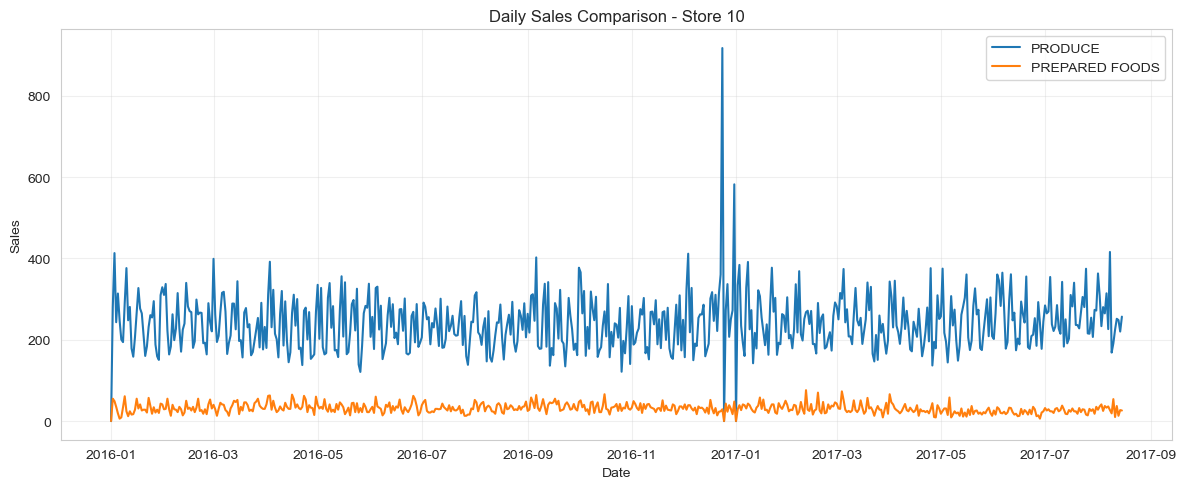

In [120]:
# Plot Product 1
# TODO: Plot product1_ts on a line chart as a time series

plt.figure(figsize=(12, 5))

plt.plot(product1_ts, label=product_family_1)
plt.plot(product2_ts, label=product_family_2)

plt.title(f"Daily Sales Comparison - Store {selected_store}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Document Your Choice (2-3 sentences)
Explain why you chose this product. 
- What contrasts do they represent? 
- Why will they be interesting to compare?

I chose produce because I personally work at the produce department in Wal Mart, and I chose prepared foods because I thought it would provide an interesting insight between food products. The difference between produce and prepared food is how processed they are. Produce is fresh food, often without any additives. Prepared foods are pre-made meals and products that have multiple different ingredients with preservatives. 

---
## Step 3: Identify Trends Using Moving Averages

### Calculate Moving Averages
Calculate the 7-day and 30-day moving averages for the product you are analyzing.

In [121]:
# TODO: Calculate 7-day and 30-day moving averages for your product

# For Product 1
product1_ma7 = product1_ts.rolling(window=7).mean()  # Replace with product1_ts.rolling(window=7).mean()
product1_ma30 = product1_ts.rolling(window=30).mean()  # Replace with product1_ts.rolling(window=30).mean()

product2_ma7 = product2_ts.rolling(window=7).mean()  # Replace with product1_ts.rolling(window=7).mean()
product2_ma30 = product2_ts.rolling(window=30).mean()

### Plot Original Sales
Using matplotlip, plot original sales with both moving averages (7-day and 30-day) overlaid.

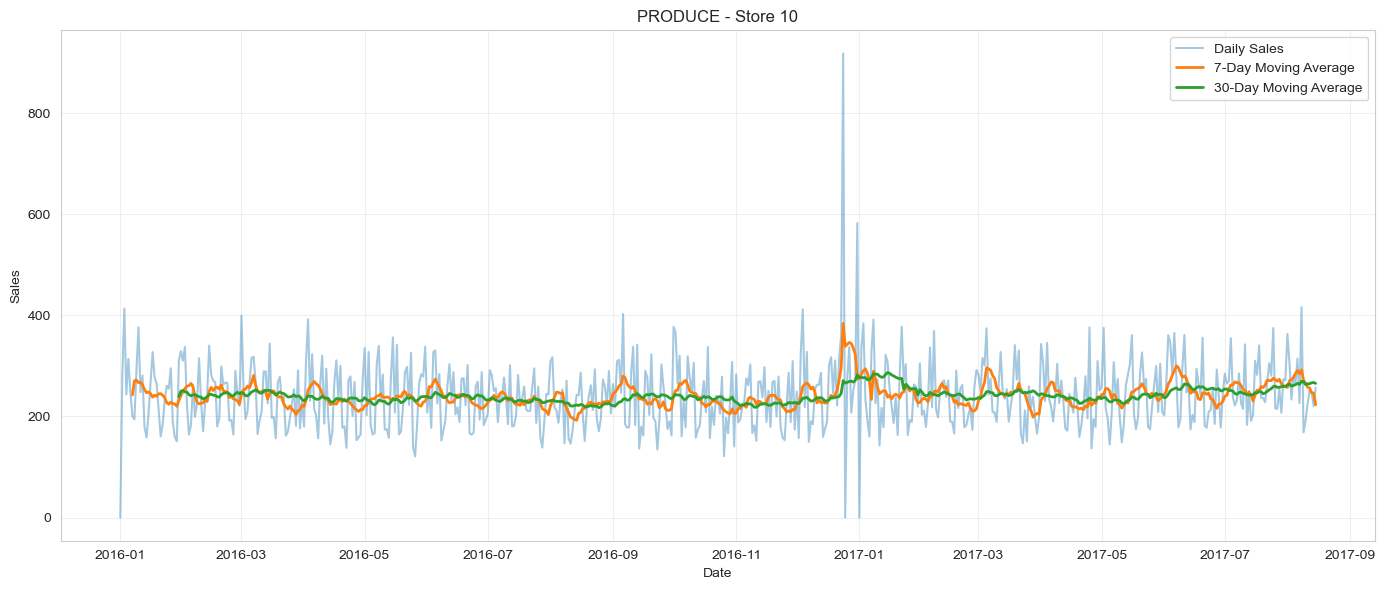

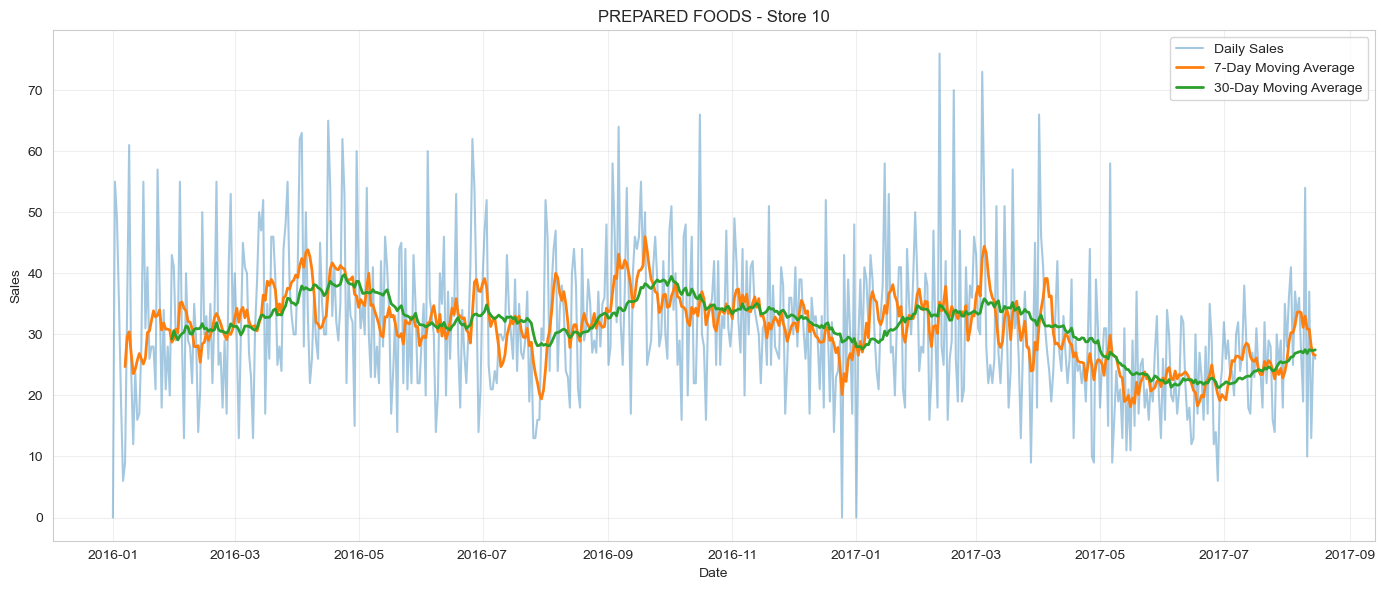

In [122]:
plt.figure(figsize=(14, 6))

# Original sales
plt.plot(product1_ts.index, product1_ts.values, 
         label="Daily Sales", alpha=0.4)

# 7-day moving average
plt.plot(product1_ma7.index, product1_ma7.values, 
         label="7-Day Moving Average", linewidth=2)

# 30-day moving average
plt.plot(product1_ma30.index, product1_ma30.values, 
         label="30-Day Moving Average", linewidth=2)

plt.title(f"{product_family_1} - Store {selected_store}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

#Original Sales
plt.plot(product2_ts.index, product2_ts.values, 
         label="Daily Sales", alpha=0.4)

# 7-day moving average
plt.plot(product2_ma7.index, product2_ma7.values, 
         label="7-Day Moving Average", linewidth=2)

# 30-day moving average
plt.plot(product2_ma30.index, product2_ma30.values, 
         label="30-Day Moving Average", linewidth=2)

plt.title(f"{product_family_2} - Store {selected_store}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Identify and Explain Trend Changes

Merge the data with `holidays_events.csv` to explain what caused these changes.

Key holidays/events in the period:
          date    sales      type    locale locale_name  \
0   2016-01-01    0.000   Holiday  National     Ecuador   
1   2016-01-02  280.001       NaN       NaN         NaN   
2   2016-01-03  413.227       NaN       NaN         NaN   
3   2016-01-04  243.187       NaN       NaN         NaN   
4   2016-01-05  313.788       NaN       NaN         NaN   
..         ...      ...       ...       ...         ...   
603 2017-08-11  224.769  Transfer  National     Ecuador   
604 2017-08-12  251.612       NaN       NaN         NaN   
605 2017-08-13  248.518       NaN       NaN         NaN   
606 2017-08-14  220.260       NaN       NaN         NaN   
607 2017-08-15  256.911   Holiday     Local    Riobamba   

                                description transferred  
0                        Primer dia del ano       False  
1                                       NaN         NaN  
2                                       NaN         NaN  
3                       

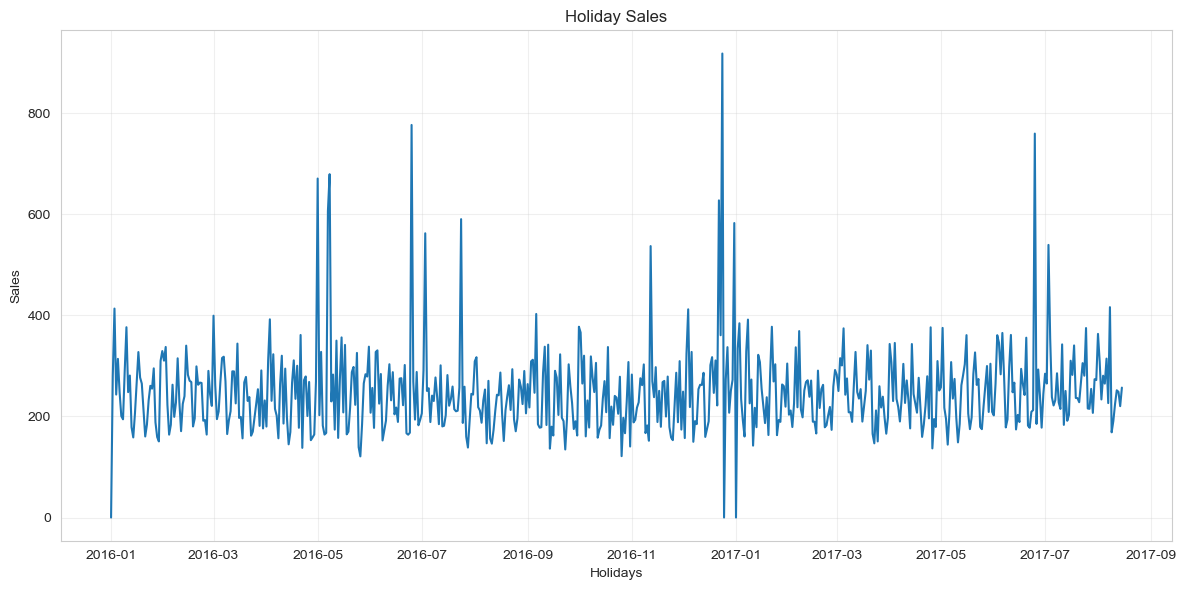

In [123]:
# Merge with holidays to explain trend changes
# TODO: Convert holidays_df date to datetime and filter for your date range
if holidays_df is not None:
    holidays_df['date'] = pd.to_datetime(holidays_df['date'])
    relevant_holidays = holidays_df[(holidays_df['date'] >= start_date) & (holidays_df['date'] <= end_date)] # Filter holidays_df for your date range
    # TODO: Display holidays that might explain trend changes
sales_df = product1_ts.rename("sales").to_frame()
sales_df = sales_df.reset_index().rename(columns={"index": "date"})
sales_with_holidays = sales_df.merge(
    relevant_holidays,
    on="date",
    how="left"
)
print("Key holidays/events in the period:")
print(sales_with_holidays)

sales_with_holidays['description'] = sales_with_holidays['description'].fillna("No Holiday")
sales_with_holidays_ts = sales_with_holidays.groupby('date')['sales'].sum().reindex(date_range, fill_value=0)
plt.plot(sales_with_holidays_ts)
plt.title(f"Holiday Sales")
plt.xlabel("Holidays")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Document Trend Analysis
For the product family you are analyzing, document:
1. For produce, there seems to be a significant spike in sales at the beginning of the year. Which matches the spike in holiday sales arounf the beginning of the year.
2. The holiday that it correlates with is Primer dia del ano, which is a national holiday in Ecuador. 
3. This could mean many things for the store, more features of fresh produce around the end and the beginning of the year, more inventory and a good chance to place produce about to go out of data on sale to get rid of old inventory. 

Update the markdown cell below with your analysis.

**Product Trends:**
- Overall trend direction: For produce, there seems to be a significant spike in sales at the beginning of the year. Which matches the spike in holiday sales arounf the beginning of the year.
- Key trend changes: Produce remains relatively constant besides the beginning/end of the year, but Holidays show significant spikes in the months of December/January, June, and August.
- Holiday correlations: The holiday that it correlates with is Primer dia del ano, which is a national holiday in Ecuador. 

- Business implications: This could mean many things for the store, more features of fresh produce around the end and the beginning of the year, more inventory and a good chance to place produce about to go out of data on sale to get rid of old inventory. 

---
## Step 4: Detect and Visualize Seasonal Patterns

Analyze the seasonal components of your sales data.

### Day-of-Week Analysis

Add day of week to your data and calculate the average sales by day. Create a bar plot to visualize the weekday patterns.

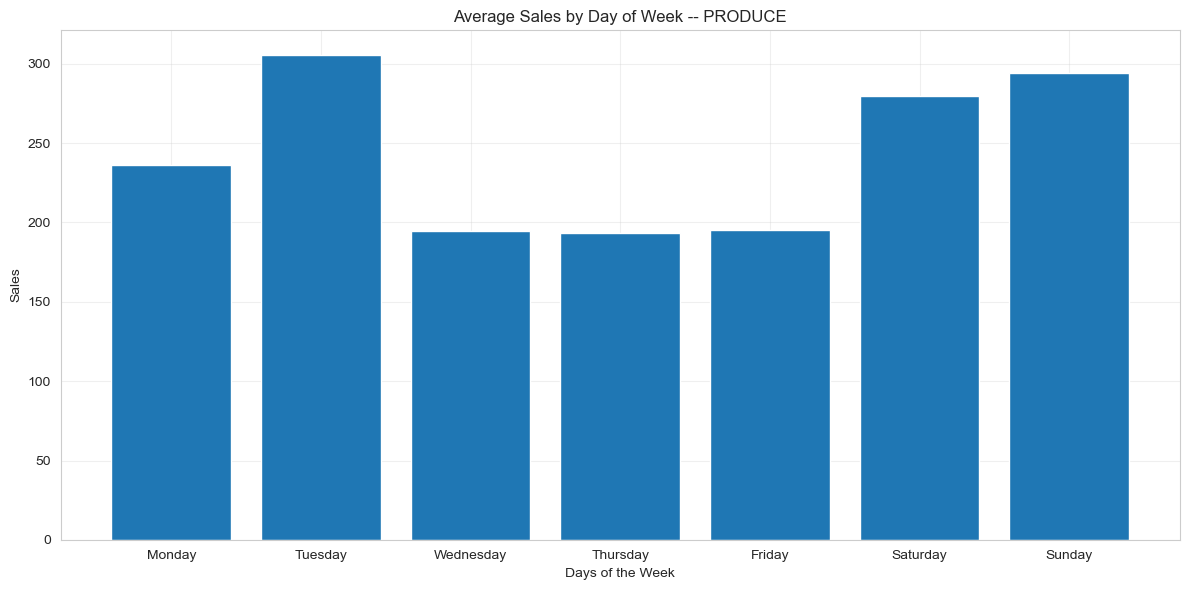

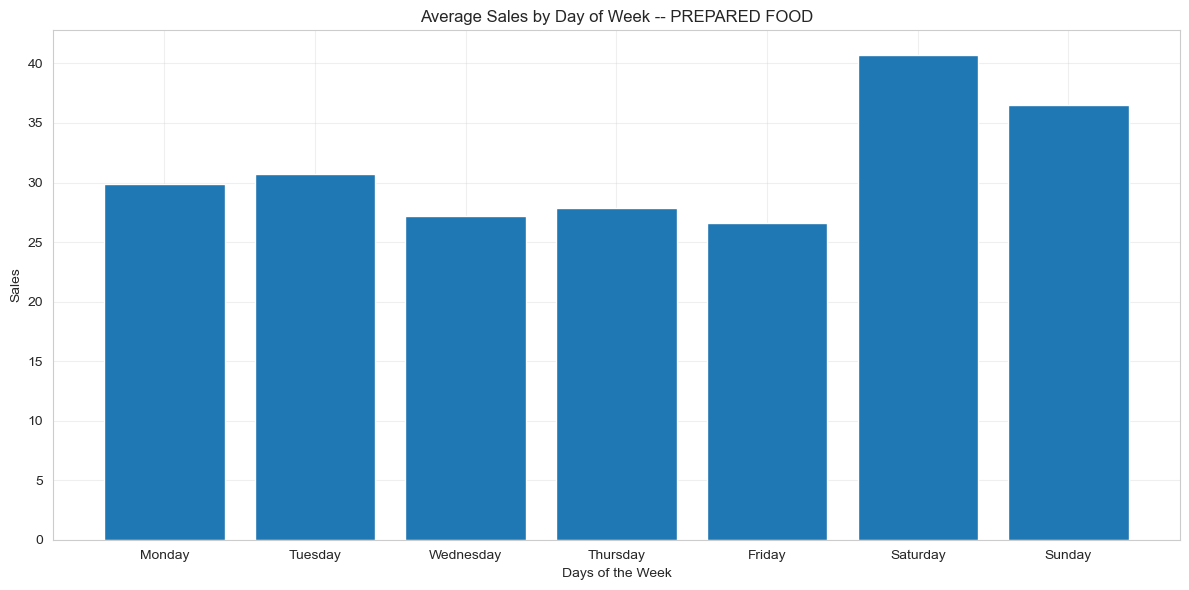

In [131]:
# Analyze day-of-week patterns
# TODO: Add day of week to your data and calculate average sales by day
product1_dow = product1_data[(product1_data['date'] >= start_date) & (product1_data['date'] <= end_date) & (product1_data['sales'])]  # Create DataFrame with date and sales
if not pd.api.types.is_datetime64_any_dtype(product1_dow['date']):
    product1_dow['date'] = pd.to_datetime(product1_dow['date'])
product1_dow['day_of_week'] = product1_dow['date'].dt.day_name()
if 'date' in product1_dow.columns:
    product1_dow = product1_dow.set_index('date')
product1_dowts = product1_dow.groupby('day_of_week')['sales'].mean()
# Add day of week: product1_dow['day_of_week'] = product1_dow.index.day_name()
# Group by day of week and calculate mean sales
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg_sales = product1_dowts.reindex(days_order)

plt.bar(dow_avg_sales.index, dow_avg_sales.values)
plt.title(f"Average Sales by Day of Week -- PRODUCE")
plt.xlabel("Days of the Week")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Product Family #2

product2_dow = product2_data[(product2_data['date'] >= start_date) & (product2_data['date'] <= end_date) & (product2_data['sales'])]  # Create DataFrame with date and sales
if not pd.api.types.is_datetime64_any_dtype(product2_dow['date']):
    product2_dow['date'] = pd.to_datetime(product2_dow['date'])
product2_dow['day_of_week'] = product2_dow['date'].dt.day_name()
if 'date' in product2_dow.columns:
    product2_dow = product2_dow.set_index('date')
product2_dowts = product2_dow.groupby('day_of_week')['sales'].mean()
# Add day of week: product1_dow['day_of_week'] = product1_dow.index.day_name()
# Group by day of week and calculate mean sales
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg_sales2 = product2_dowts.reindex(days_order)

plt.bar(dow_avg_sales2.index, dow_avg_sales2.values)
plt.title(f"Average Sales by Day of Week -- PREPARED FOOD")
plt.xlabel("Days of the Week")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Create bar plot comparing weekday patterns
# TODO: Create bar plot showing average sales by day of week

### Monthly Seasonality Analysis

Calculate the average sales by month for both products. Once calculated, create a line plot showing monthly patterns for the product.

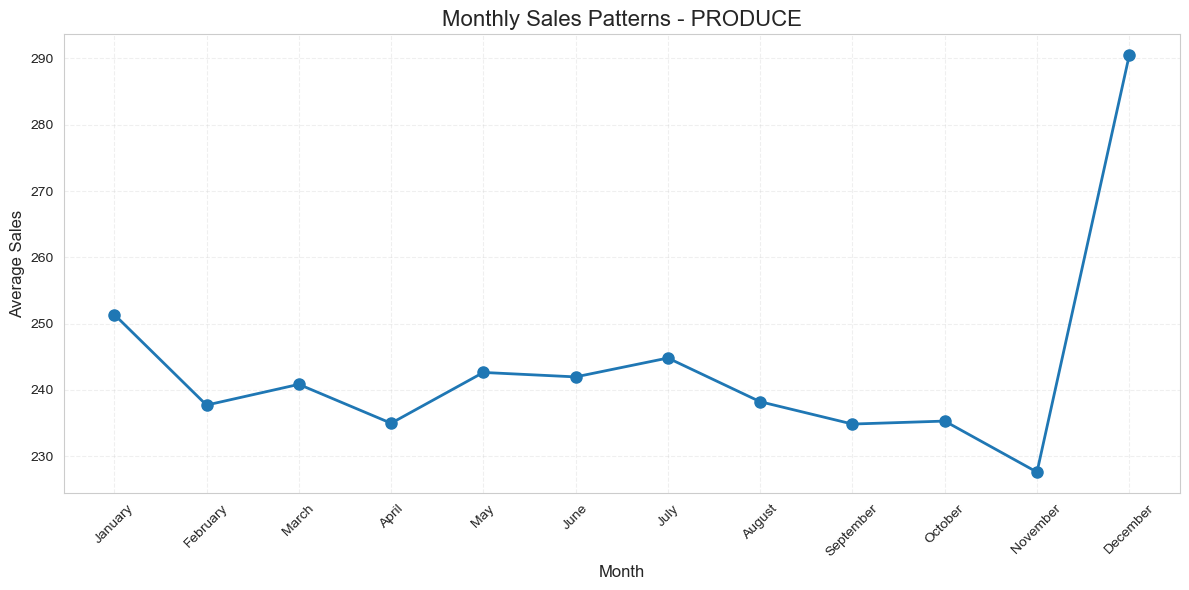

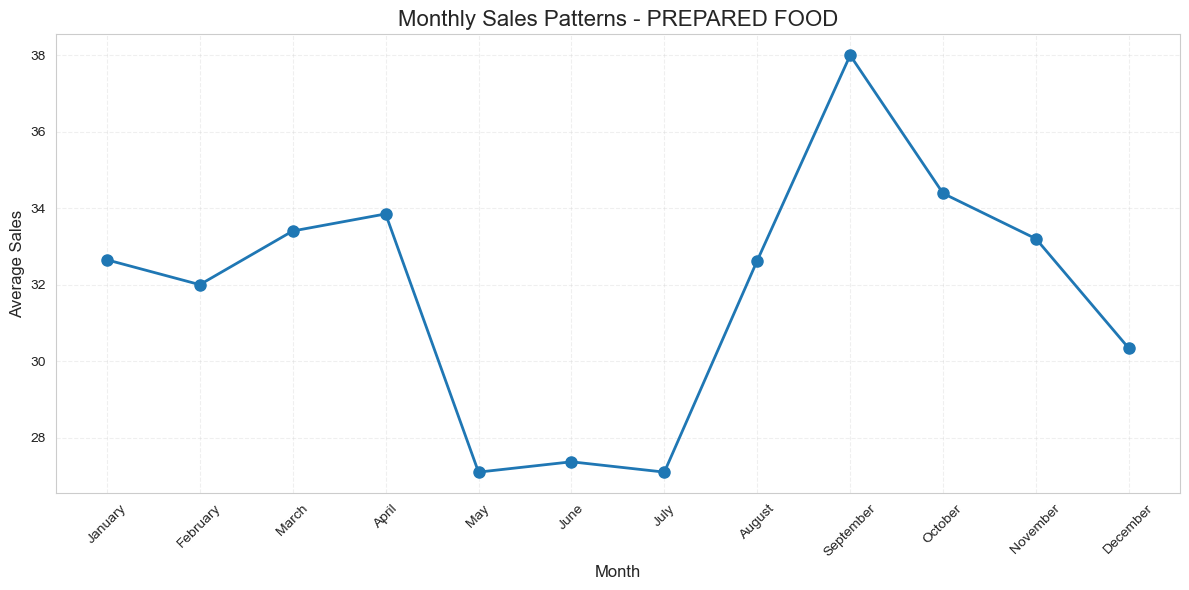

In [133]:
# Analyze monthly patterns
# TODO: Calculate average sales by month for the product.

# For Product 1
product1_monthly = product1_data[(product1_data['date'] >= start_date) & (product1_data['date'] <= end_date) & (product1_data['sales'])]# Group by month and calculate mean sales
if not pd.api.types.is_datetime64_any_dtype(product1_monthly['date']):
    product1_monthly['date'] = pd.to_datetime(product1_monthly['date'])
product1_monthly['month'] = product1_monthly['date'].dt.month_name()
if 'date' in product1_monthly.columns:
    product1_monthly = product1_monthly.set_index('date')
product1_monthlyts = product1_monthly.groupby('month')['sales'].mean()
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_avg_sales = product1_monthlyts.reindex(months_order)
plt.plot(monthly_avg_sales.index, monthly_avg_sales.values, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.title("Monthly Sales Patterns - PRODUCE", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Sales", fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# For Product 2
product2_monthly = product2_data[(product2_data['date'] >= start_date) & (product2_data['date'] <= end_date) & (product2_data['sales'])]# Group by month and calculate mean sales
if not pd.api.types.is_datetime64_any_dtype(product2_monthly['date']):
    product2_monthly['date'] = pd.to_datetime(product2_monthly['date'])
product2_monthly['month'] = product2_monthly['date'].dt.month_name()
if 'date' in product2_monthly.columns:
    product2_monthly = product2_monthly.set_index('date')
product2_monthlyts = product2_monthly.groupby('month')['sales'].mean()
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_avg_sales2 = product2_monthlyts.reindex(months_order)
plt.plot(monthly_avg_sales2.index, monthly_avg_sales2.values, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.title("Monthly Sales Patterns - PREPARED FOOD", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Sales", fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Create visualization
# TODO: Create line plot showing monthly patterns for both products

### Holiday Impact Analysis

Compare the average sales on holidays compared to regular days.

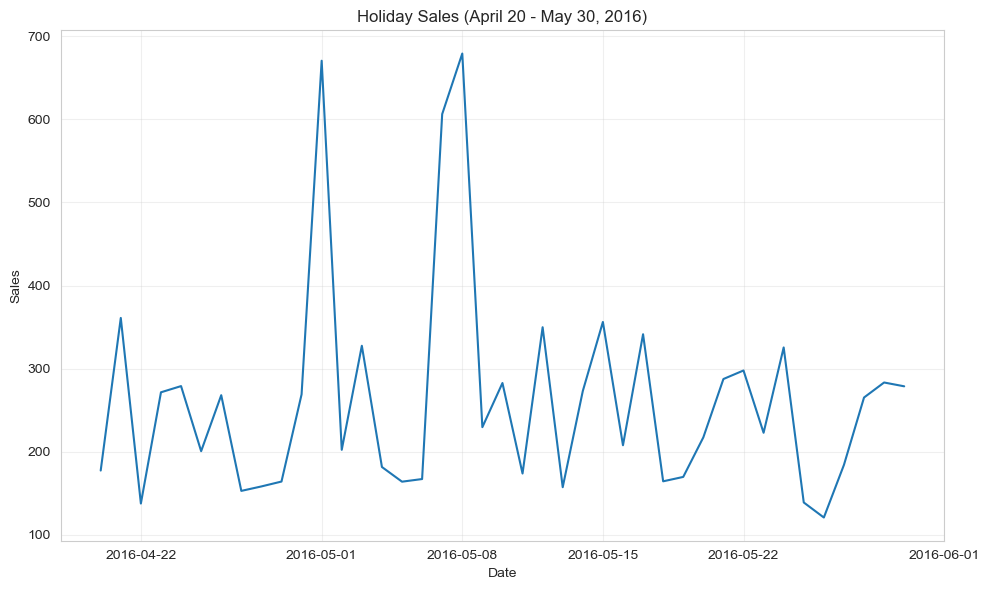

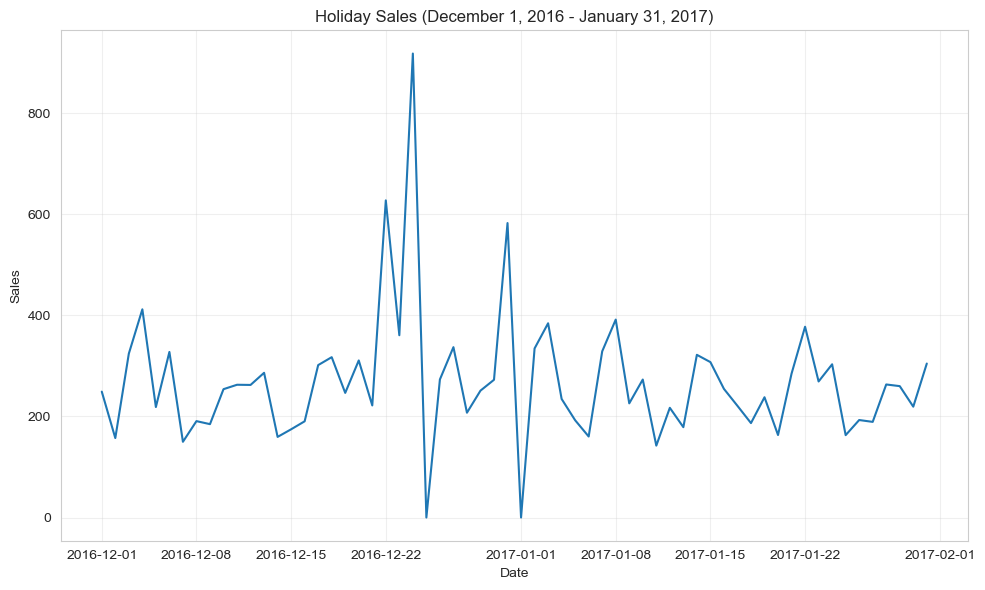

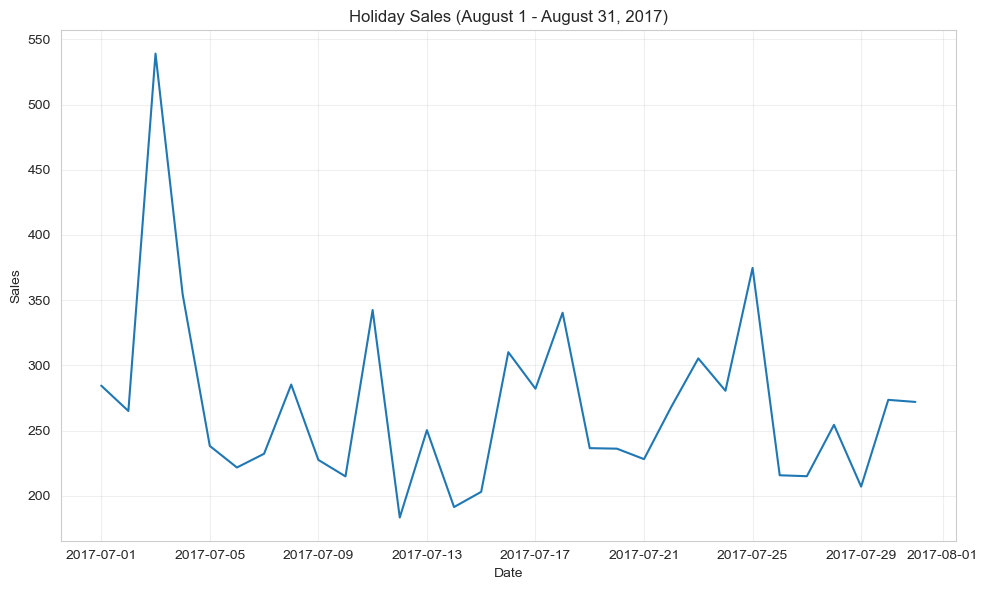

In [143]:
# Analyze holiday vs non-holiday sales
# TODO: Compare average sales on holidays vs regular days
# Create a list of holiday dates
holiday_start1 = '2016-12-01'
holiday_end1 = '2017-01-31'
holiday_start2 = '2016-04-20'
holiday_end2 = '2016-05-30'
holiday_start3 = '2017-07-01'
holiday_end3 = '2017-07-31'

holiday_dates1 = None
holiday_dates2 = None
holiday_dates3 = None

if holidays_df is not None:
    holidays_df['date'] = pd.to_datetime(holidays_df['date'])
    holiday_dates1 = holidays_df[(holidays_df['date'] >= pd.to_datetime(holiday_start2)) & (holidays_df['date'] <= pd.to_datetime(holiday_end2))]
    holiday_dates2 = holidays_df[(holidays_df['date'] >= pd.to_datetime(holiday_start1)) & (holidays_df['date'] <= pd.to_datetime(holiday_end1))]
    holiday_dates3 = holidays_df[(holidays_df['date'] >= pd.to_datetime(holiday_start3)) & (holidays_df['date'] <= pd.to_datetime(holiday_end3))] # Filter holidays_df for your date range
    # TODO: Display holidays that might explain trend changes
sales_df = product1_ts.rename("sales").to_frame()
sales_df = sales_df.reset_index().rename(columns={"index": "date"})

#HOLIDAY SPIKE #1

if not holiday_dates1.empty:
    sales_with_holidays1 = sales_df.merge(
        holiday_dates1,
        on="date",
        how="left"
    )
filtered_sales = sales_with_holidays1[
            (sales_with_holidays1['date'] >= pd.to_datetime(holiday_start2)) & 
            (sales_with_holidays1['date'] <= pd.to_datetime(holiday_end2))
        ]

sales_with_holidays1['description'] = sales_with_holidays1['description'].fillna("No Holiday")
sales_with_holidays_ts1 = filtered_sales.groupby('date')['sales'].sum()
plt.figure(figsize=(10, 6))
plt.plot(sales_with_holidays_ts1.index, sales_with_holidays_ts1.values)
plt.title(f"Holiday Sales (April 20 - May 30, 2016)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#HOLIDAY SPIKE #2

if not holiday_dates2.empty:
    sales_with_holidays2 = sales_df.merge(
        holiday_dates2,
        on="date",
        how="left"
    )
filtered_sales = sales_with_holidays2[
            (sales_with_holidays2['date'] >= pd.to_datetime(holiday_start1)) & 
            (sales_with_holidays2['date'] <= pd.to_datetime(holiday_end1))
        ]

sales_with_holidays2['description'] = sales_with_holidays2['description'].fillna("No Holiday")
sales_with_holidays_ts2 = filtered_sales.groupby('date')['sales'].sum()
plt.figure(figsize=(10, 6))
plt.plot(sales_with_holidays_ts2.index, sales_with_holidays_ts2.values)
plt.title(f"Holiday Sales (December 1, 2016 - January 31, 2017)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#HOLIDAY SPIKE #3 

if not holiday_dates3.empty:
    sales_with_holidays3 = sales_df.merge(
        holiday_dates3,
        on="date",
        how="left"
    )
filtered_sales = sales_with_holidays3[
            (sales_with_holidays3['date'] >= pd.to_datetime(holiday_start3)) & 
            (sales_with_holidays3['date'] <= pd.to_datetime(holiday_end3))
        ]

sales_with_holidays3['description'] = sales_with_holidays3['description'].fillna("No Holiday")
sales_with_holidays_ts3 = filtered_sales.groupby('date')['sales'].sum()
plt.figure(figsize=(10, 6))
plt.plot(sales_with_holidays_ts3.index, sales_with_holidays_ts3.values)
plt.title(f"Holiday Sales (August 1 - August 31, 2017)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate average sales on holidays vs non-holidays for both products
# TODO: Split data into holiday and non-holiday sales and compare

average_holiday_sales = [(holiday_df['

### Seasonal Pattern Findings

**Document your findings:**
- Which days of the week have highest/lowest sales?
- Are there monthly patterns (e.g., payday effects)?
- How do holidays affect each product differently?
- What business decisions could these patterns inform?

Update the markdown cell below with your analysis.

# 1. The days of the week with the highest sales in Produce is Tuesday. The day of the week with the lowest sales in Produce is Thursday. The day of the week with the highest sales in Prepared Food is Saturday. The day of the week with the lowest sales in Prepared Food is Friday.
---------------
# 2. For Produce there is a significant spike in sales in November and December. I believe this could be because holidays like Thanksgiving and Christmas normally involve meals with family, and a part of those meals is fresh veggies and fruit. For Prepared Foods, there is a significant spike in August and September, and this could be for school sponsored canned food drives.
---------------
# 3 As aparent by our Holiday sales through December, there is a significant spike at Christmas, which directly affects Produce. This is because of how much produce families use for their Christmas Parties.
---------------
# 4 These patterns can inform us to push Produce more heavily through holidays like Thanksgiving and Christmas, because sales have been significant on those dates. As for canned foods/prepared foods, market more prepared foods during August because canned drives, and back to school lunches. 

---
## Step 5: Build Simple Forecasts and Compare Methods

### Time Series Decomposition

PRODUCE


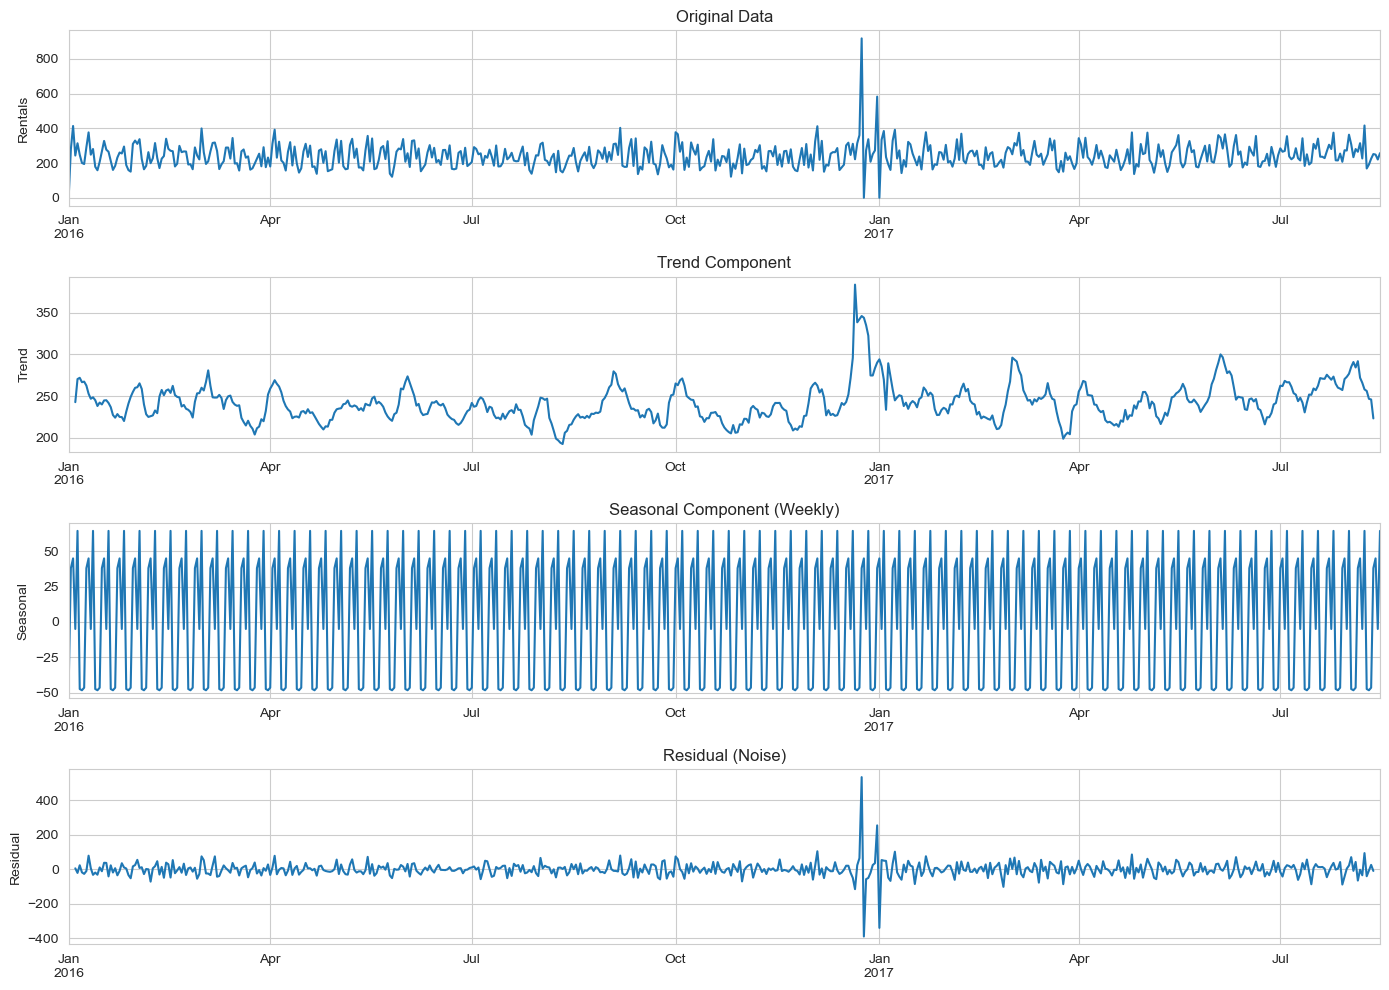

PPREPARED FOODS


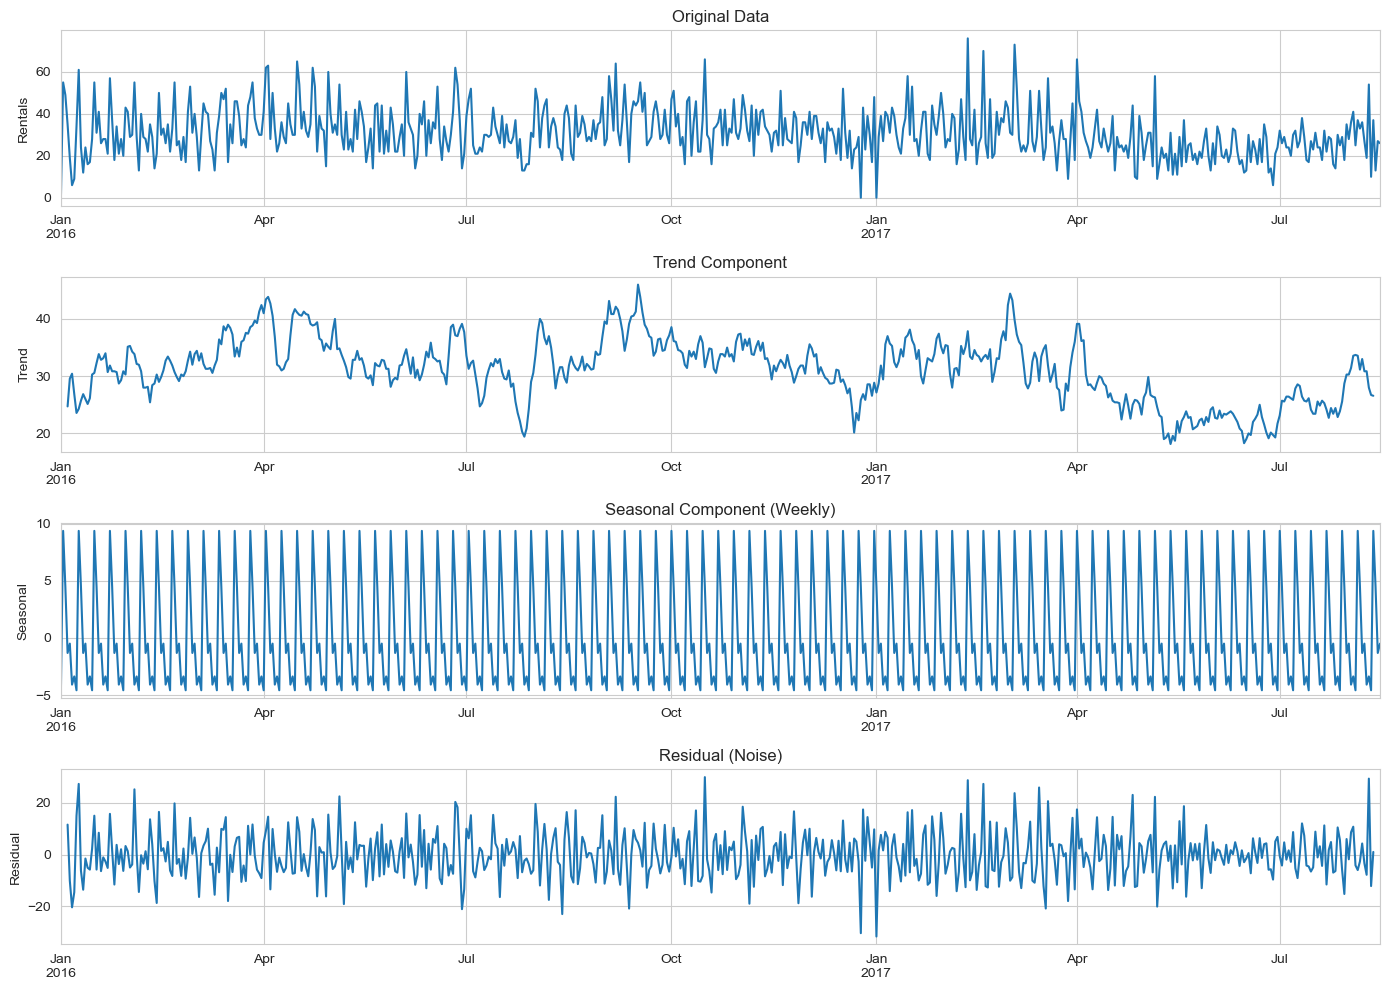

In [147]:
# Perform seasonal decomposition
# TODO: Use seasonal_decompose to separate trend, seasonal, and residual components
print("PRODUCE")
# For Product 1
decomposition1 = seasonal_decompose(product1_ts, model='additive', period=7)  # seasonal_decompose(product1_ts, model='additive', period=7)
if decomposition1 is not None:
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
product1_ts.plot(ax=axes[0], title='Original Data')
axes[0].set_ylabel('Rentals')

decomposition1.trend.plot(ax=axes[1], title='Trend Component')
axes[1].set_ylabel('Trend')

decomposition1.seasonal.plot(ax=axes[2], title='Seasonal Component (Weekly)')
axes[2].set_ylabel('Seasonal')

decomposition1.resid.plot(ax=axes[3], title='Residual (Noise)')
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.show()

print("PPREPARED FOODS")
# For Product 2
decomposition2 = seasonal_decompose(product2_ts, model='additive', period=7)
if decomposition2 is not None:
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
product2_ts.plot(ax=axes[0], title='Original Data')
axes[0].set_ylabel('Rentals')

decomposition2.trend.plot(ax=axes[1], title='Trend Component')
axes[1].set_ylabel('Trend')

decomposition2.seasonal.plot(ax=axes[2], title='Seasonal Component (Weekly)')
axes[2].set_ylabel('Seasonal')

decomposition2.resid.plot(ax=axes[3], title='Residual (Noise)')
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.show()


### Build Forecasts
Create a baseline forecast using the average of the last 30 days and a season naive forcast by repeating the last 7 days' pattern.

In [151]:
#PRODUCT 1
print("PRODUCE")
# Split data for validation
test_days = 30
train_1ts = product1_ts[:-test_days] # product1_ts[:-test_days]
test_1ts = product1_ts[-test_days:] # product1_ts[-test_days:]
print(f"Training on: {len(train_1ts)} days")
print(f"Testing on: {len(test_1ts)} days")
# Method 1: Baseline forecast (30-day average)
baseline_forecast = np.repeat(train_1ts[-30:].mean(), test_days)
print(f"Baseline forecast: {baseline_forecast[0]:.0f}")
# Method 2: Seasonal Naive
# Just repeat the last 7 days pattern
last_week_1ts = train_1ts[-7:].values
seasonal_naive_forecast_1ts = np.tile(last_week_1ts, int(np.ceil(test_days/7)))[:test_days]
print("Seasonal naive forecast (first 7 days):")
for i, day in enumerate(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']):
    print(f"  {day}: {seasonal_naive_forecast_1ts[i]:.0f} rentals")

#FOR PRODUCT 2
print("")
print("PREPARED FOODS")
test_days = 30
train_2ts = product2_ts[:-test_days] # product1_ts[:-test_days]
test_2ts = product2_ts[-test_days:] # product1_ts[-test_days:]
print(f"Training on: {len(train_2ts)} days")
print(f"Testing on: {len(test_2ts)} days")
# Method 1: Baseline forecast (30-day average)
baseline_forecast2 = np.repeat(train_2ts[-30:].mean(), test_days)
print(f"Baseline forecast: {baseline_forecast2[0]:.0f}")
# Method 2: Seasonal Naive
# Just repeat the last 7 days pattern
last_week_2ts = train_2ts[-7:].values
seasonal_naive_forecast_2ts = np.tile(last_week_2ts, int(np.ceil(test_days/7)))[:test_days]
print("Seasonal naive forecast (first 7 days):")
for i, day in enumerate(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']):
    print(f"  {day}: {seasonal_naive_forecast_2ts[i]:.0f} rentals")

PRODUCE
Training on: 563 days
Testing on: 30 days
Baseline forecast: 247
Seasonal naive forecast (first 7 days):
  Mon: 215 rentals
  Tue: 342 rentals
  Wed: 183 rentals
  Thu: 250 rentals
  Fri: 191 rentals
  Sat: 203 rentals
  Sun: 310 rentals

PREPARED FOODS
Training on: 563 days
Testing on: 30 days
Baseline forecast: 24
Seasonal naive forecast (first 7 days):
  Mon: 27 rentals
  Tue: 38 rentals
  Wed: 29 rentals
  Thu: 18 rentals
  Fri: 17 rentals
  Sat: 27 rentals
  Sun: 23 rentals


### Calculate Forecast Accuracy

In [154]:
# Calculate RMSE for both methods
# TODO: Calculate RMSE for baseline and seasonal forecasts

# Product 1
baseline_rmse = np.sqrt(mean_squared_error(test_1ts, baseline_forecast))  # np.sqrt(mean_squared_error(test1, baseline_forecast1)
seasonal_rmse = np.sqrt(mean_squared_error(test_1ts, seasonal_naive_forecast_1ts))  # np.sqrt(mean_squared_error(test1, seasonal_naive_forecast))
print(f"Baseline RMSE for PRODUCE: {baseline_rmse}")
print(f"Seasonal RMSE for PRODUCE: {seasonal_rmse}")
#Product 2
baseline_rmse2 = np.sqrt(mean_squared_error(test_2ts, baseline_forecast2))  # np.sqrt(mean_squared_error(test1, baseline_forecast1)
seasonal_rmse2 = np.sqrt(mean_squared_error(test_2ts, seasonal_naive_forecast_2ts))  # np.sqrt(mean_squared_error(test1, seasonal_naive_forecast))
print(f"Baseline RMSE for PREPARED FOOD: {baseline_rmse2}")
print(f"Seasonal RMSE for PREPARED FOOD: {seasonal_rmse2}")

Baseline RMSE for PRODUCE: 57.72216849535429
Seasonal RMSE for PRODUCE: 52.07952809866212
Baseline RMSE for PREPARED FOOD: 9.765528943972035
Seasonal RMSE for PREPARED FOOD: 12.20245876862528


In [158]:
# Create comparison table
comparison_data = {
    'Method': ['30-Day Average', 'Seasonal Naive (7-day repeat)'],
    'RMSE': [baseline_rmse, seasonal_rmse],
}

comparison_df = pd.DataFrame(comparison_data)

# TODO: Calculate percentage improvement
# Add improvement column to comparison_d

print("\n" + "="*80)
print("FORECAST PERFORMANCE COMPARISON")
print("="*80)
# TODO: Display comparison table
if seasonal_rmse < baseline_rmse:
    improvement1 = (baseline_rmse - seasonal_rmse) / baseline_rmse * 100
    print(f"  → PRODUCE Seasonal naive is {improvement1:.1f}% better!")
if baseline_rmse < seasonal_rmse:
    improvement1 = (seasonal_rmse - baseline_rmse) / seasonal_rmse * 100
    print(f"  → PRODUCE Baseline is {improvement1:.1f}% better!")
if seasonal_rmse2 < baseline_rmse2:
    improvement2 = (baseline_rmse2 - seasonal_rmse2) / baseline_rmse2 * 100
    print(f"  → PREPARED FOODS Seasonal naive is {improvement2:.1f}% better!")
if baseline_rmse2 < seasonal_rmse2:
    improvement2 = (seasonal_rmse2 - baseline_rmse2) / seasonal_rmse2 * 100
    print(f"  → PREPARED FOODS Baseline is {improvement2:.1f}% better!")

print("="*80)


FORECAST PERFORMANCE COMPARISON
  → PRODUCE Seasonal naive is 9.8% better!
  → PREPARED FOODS Baseline is 20.0% better!


### Visualize Forecasts

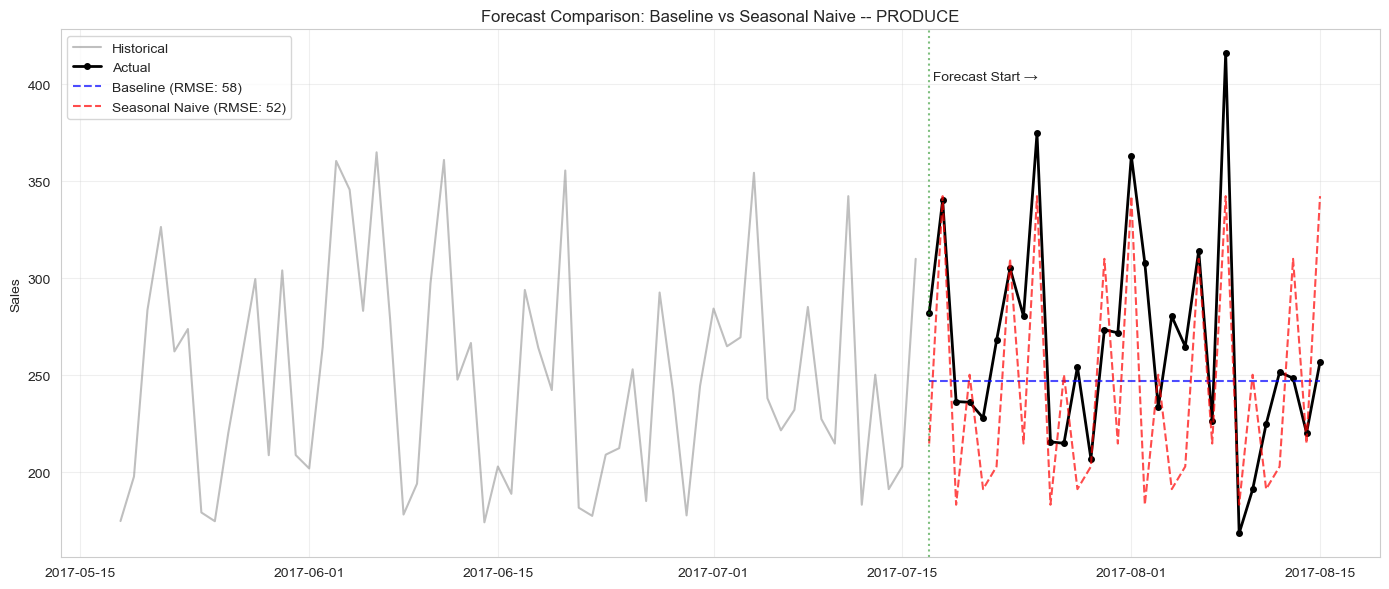

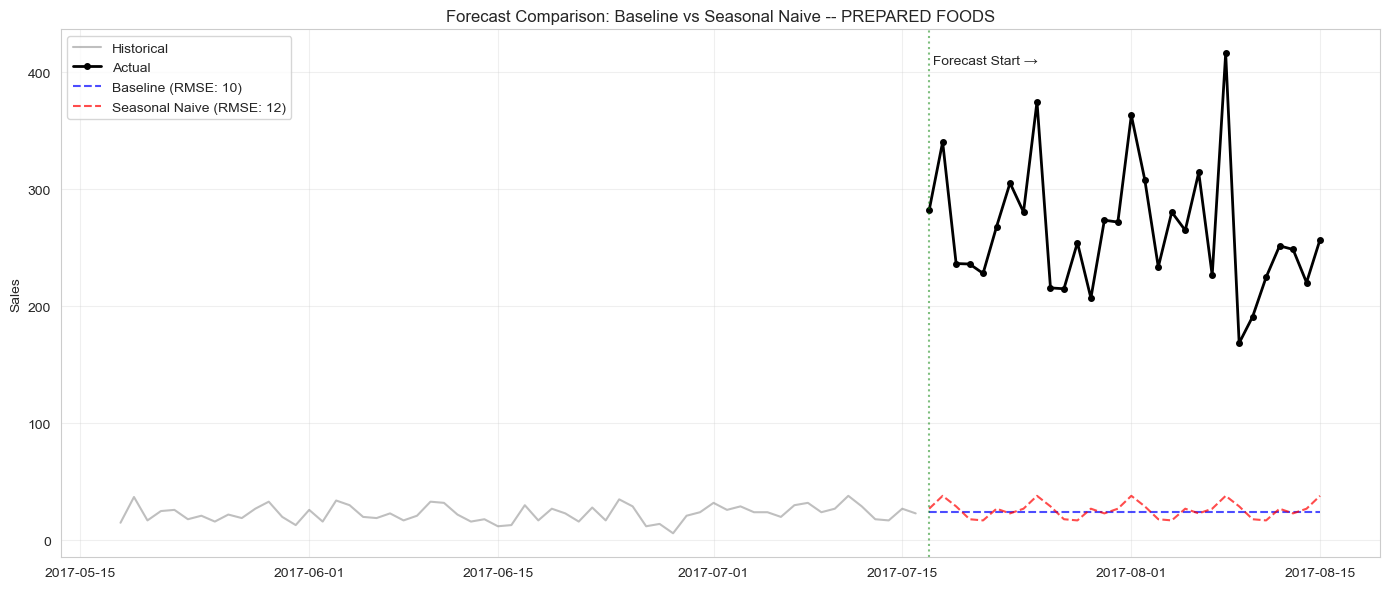

In [163]:
# Plot actual vs forecasted values
# TODO: Create visualization showing:
# - Historical data (last 60 days of train)
# - Actual test data
# - Baseline forecast
# - Seasonal naive forecast

#PRODUCT 1
plt.figure(figsize=(14, 6))
plt.plot(train_1ts.index[-60:], train_1ts.values[-60:], 
         label='Historical', color='gray', alpha=0.5)
plt.plot(test_1ts.index, test_1ts.values, 
         label='Actual', color='black', linewidth=2, marker='o', markersize=4)
plt.plot(test_1ts.index, baseline_forecast, 
         label=f'Baseline (RMSE: {baseline_rmse:.0f})', 
         linestyle='--', color='blue', alpha=0.7)
plt.plot(test_1ts.index, seasonal_naive_forecast_1ts, 
         label=f'Seasonal Naive (RMSE: {seasonal_rmse:.0f})', 
         linestyle='--', color='red', alpha=0.7)
plt.axvline(x=test_1ts.index[0], color='green', linestyle=':', alpha=0.5)
plt.text(test_1ts.index[0], plt.ylim()[1]*0.95, ' Forecast Start →', 
         verticalalignment='top')
plt.title('Forecast Comparison: Baseline vs Seasonal Naive -- PRODUCE')
plt.ylabel('Sales')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#PRODUCT 2
plt.figure(figsize=(14, 6))
plt.plot(train_2ts.index[-60:], train_2ts.values[-60:], 
         label='Historical', color='gray', alpha=0.5)
plt.plot(test_2ts.index, test_1ts.values, 
         label='Actual', color='black', linewidth=2, marker='o', markersize=4)
plt.plot(test_2ts.index, baseline_forecast2, 
         label=f'Baseline (RMSE: {baseline_rmse2:.0f})', 
         linestyle='--', color='blue', alpha=0.7)
plt.plot(test_2ts.index, seasonal_naive_forecast_2ts, 
         label=f'Seasonal Naive (RMSE: {seasonal_rmse2:.0f})', 
         linestyle='--', color='red', alpha=0.7)
plt.axvline(x=test_2ts.index[0], color='green', linestyle=':', alpha=0.5)
plt.text(test_2ts.index[0], plt.ylim()[1]*0.95, ' Forecast Start →', 
         verticalalignment='top')
plt.title('Forecast Comparison: Baseline vs Seasonal Naive -- PREPARED FOODS')
plt.ylabel('Sales')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 6: Generate Business Recommendations

### Executive Summary (200-300 words)

Based on your analysis, write a brief executive summary that includes:
- **Key Patterns Discovered:** Summarize the main trends and seasonal patterns for each product
- **Inventory Planning Recommendations:** Specific recommendations based on your findings
- **High-Risk Periods:** Identify periods requiring special attention
- **Predictability Analysis:** Which product is more predictable and why?
- **Specific Action Item:** One concrete action the store manager should take based on your forecast

### The key patterns I discovered for Produce are that sales typically increase during the holiday months of November and December, with Tuesday being Produce’s strongest day for sales. For Prepared Foods, sales tend to increase during August and September, with Saturday being the best-performing day. Based on these findings, I would order additional Produce inventory before November and continue increasing inventory levels through the New Year. I would also recommend ordering more Prepared Foods inventory during August and September when school is starting.Both products remain relatively stable throughout the rest of the year in terms of sales. 
### However, to prevent fresh Produce from going to waste, I would recommend displaying it at the front of the store or near checkout areas on Wednesdays, Thursdays, and Fridays to help boost midweek sales. Produce appears to be the more predictable product, likely because customers regularly purchase it during routine grocery trips, and our forecasts support this conclusion. One concrete action the store manager should take based on this forecast is to prioritize the Produce department. Specifically, the manager should focus on marketing Produce more aggressively on Wednesdays, Thursdays, and Fridays, as those are the weakest sales days for that category. 

---
## Step 7: Submit Your Work

Before submitting:
1. Ensure all code cells run without errors
2. Verify all visualizations display correctly
3. Check that your analysis sections are complete
4. Review your executive summary

Push to GitHub:
```bash
git add .
git commit -m 'completed time series forecasting assignment'
git push
```

Submit your GitHub repository link on the course platform.